<a href="https://colab.research.google.com/github/sparsetrace/DMAE/blob/main/DMAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DMAE: Diffusion Map Autoencoder




In [1]:
import os, sys, subprocess as sbp
import numpy as np

import matplotlib.pyplot as plt
import plotly.graph_objects as go

os.environ["PIP_DISABLE_PIP_VERSION_CHECK"] = "1"
try:
    from dmae import DMAE, DMAP, GPLM
    from dmae.plot_helper import compare_3d_plots
except:
    sbp.check_call([sys.executable, "-m", "pip", "install", "git+https://github.com/sparsetrace/DMAE.git"])
    from dmae import DMAE, DMAP, GPLM
    from dmae.plot_helper import compare_3d_plots

from sklearn.datasets import make_swiss_roll, make_s_curve

# Swiss-Roll

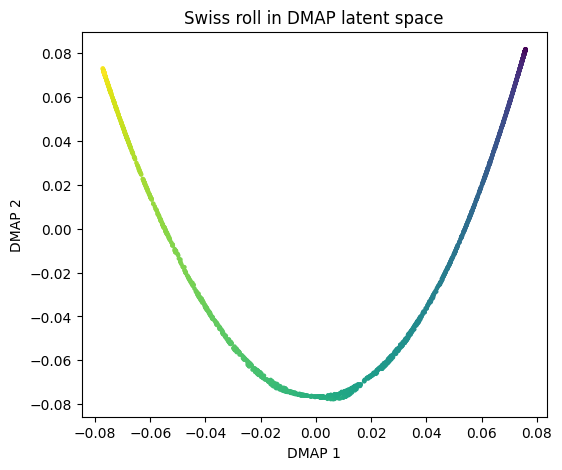

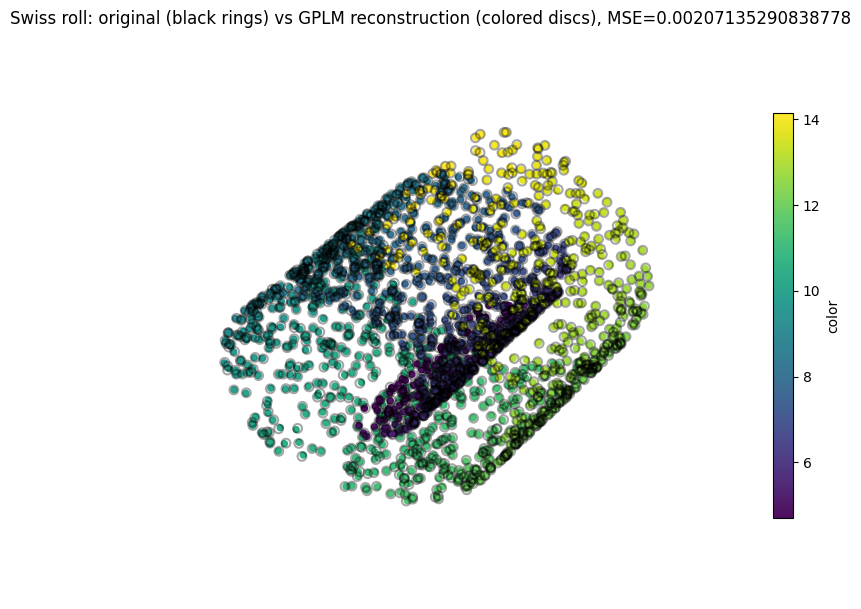

In [2]:
R_iX, color = make_swiss_roll(n_samples=2000, noise=0.0)
R_iX = R_iX.astype(np.float32)

encoder = DMAP(R_iX, d=64, h=1, beta=0.5)

R_ix    = encoder(R_iX)

decoder = GPLM(R_ix=R_ix, R_iX=R_iX)

Q_iX    = decoder(R_ix)

plt.figure(figsize=(6, 5))
plt.scatter(R_ix[:, 0, 0], R_ix[:, 0, 1], c=color, s=5)
plt.xlabel("DMAP 1")
plt.ylabel("DMAP 2")
plt.title("Swiss roll in DMAP latent space")
plt.show()

mse_per_dim = np.mean((Q_iX - R_iX) ** 2, axis=0)

title = f"Swiss roll: original (black rings) vs GPLM reconstruction (colored discs), MSE={mse_per_dim.mean()}"
compare_3d_plots(R_iX, Q_iX, color, title, axis=False, backend="matplotlib")

## Autoencoder API

In [3]:
R_iX, color = make_swiss_roll(n_samples=2000, noise=0.0)
R_iX = R_iX.astype(np.float32)

Model = DMAE(R_iX, d=32)

Q_ix = Model.encode(R_iX)   # (N, 1, 32)
Q_iX = Model(Q_ix)          # decode latent -> ambient
# same as:
# Q_iX = Model.decode(Q_ix)

# full reconstruction directly from ambient:
Rhat_iX = Model.reconstruct(R_iX)

mse_per_dim = np.mean((Rhat_iX - R_iX) ** 2, axis=0)
print("MSE per dim:", mse_per_dim)
print("Total MSE:", mse_per_dim.mean())



MSE per dim: [2.0829467e-07 1.2301642e-06 2.5955373e-07]
Total MSE: 5.6600425e-07


# S-curve

MSE per dim: [7.7799678e-09 3.0441655e-08 1.2585191e-08]
Total MSE: 1.6935603e-08


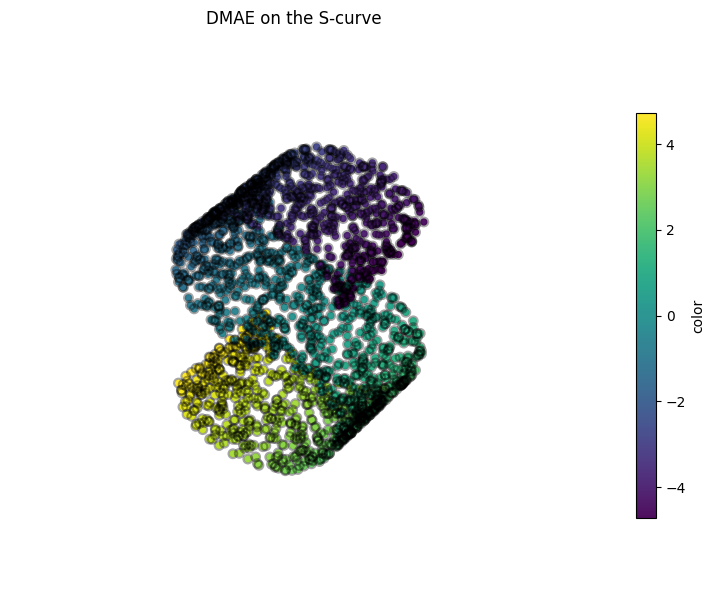

In [4]:
# Generate S-curve
R_iX, color = make_s_curve(n_samples=2000, noise=0.0, random_state=0)
R_iX = R_iX.astype(np.float32)

# Build exact dense DMAE
Model = DMAE(R_iX, d=32, h=1)

# Encode and decode
Q_ix = Model(R_iX)          # since last dim == ambient D, this encodes
Q_iX = Model(Q_ix)          # since last dim == latent d, this decodes

# Convert to numpy
Q_ix = np.asarray(Q_ix)     # (N, 1, d)
Q_iX = np.asarray(Q_iX)     # (N, 3)

# MSE
mse_per_dim = np.mean((Q_iX - R_iX) ** 2, axis=0)
mse_total = mse_per_dim.mean()
print("MSE per dim:", mse_per_dim)
print("Total MSE:", mse_total)

# Plot original as black rings, reconstruction as colored filled points
title = "DMAE on the S-curve"
compare_3d_plots(R_iX, Q_iX, color, title, axis=False, backend="matplotlib")

# Transport

Latent alignment MSE: 1.0906683e-05
Ambient transfer MSE to S-curve targets: 0.00038970343


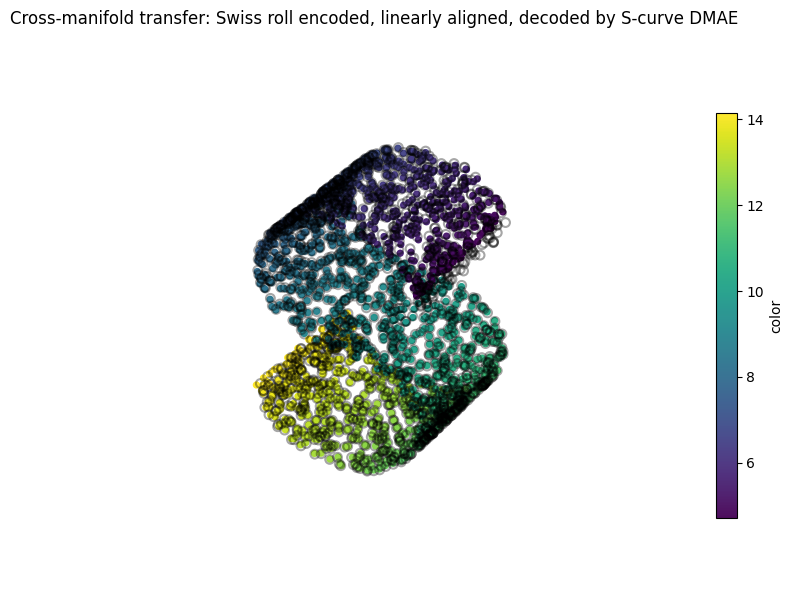

In [5]:
# ------------------------------------------------------------
# 1. Build paired-ish toy datasets
# ------------------------------------------------------------
N = 2000
d_lat = 32

R_iX_swiss, color_swiss = make_swiss_roll(n_samples=N, noise=0.0, random_state=0)
R_iX_swiss = R_iX_swiss.astype(np.float32)

R_iX_scurve, color_scurve = make_s_curve(n_samples=N, noise=0.0, random_state=0)
R_iX_scurve = R_iX_scurve.astype(np.float32)

# ------------------------------------------------------------
# 2. Build two DMAE models with the same latent size
# ------------------------------------------------------------
Swiss_roll = DMAE(R_iX_swiss, d=d_lat, h=1)
S_curve    = DMAE(R_iX_scurve, d=d_lat, h=1)

# ------------------------------------------------------------
# 3. Encode both manifolds
#    DMAE.encode returns shape (N, h, d), so squeeze head axis
# ------------------------------------------------------------
Z_swiss = np.asarray(Swiss_roll.encode(R_iX_swiss))[:, 0, :]   # (N, d)
Z_s     = np.asarray(S_curve.encode(R_iX_scurve))[:, 0, :]     # (N, d)

# ------------------------------------------------------------
# 4. Learn a linear map A_{xy} from Swiss latent -> S latent
#    We'll do ridge regression:
#         Z_swiss_centered @ A ≈ Z_s_centered
# ------------------------------------------------------------
mu_swiss = Z_swiss.mean(axis=0, keepdims=True)
mu_s     = Z_s.mean(axis=0, keepdims=True)

Z1 = Z_swiss - mu_swiss
Z2 = Z_s     - mu_s

lam = 1e-4
A_xy = np.linalg.solve(
    Z1.T @ Z1 + lam * np.eye(Z1.shape[1], dtype=np.float32),
    Z1.T @ Z2,
).astype(np.float32)   # (d, d)

# Align Swiss latents into the S-curve latent chart
Z_swiss_to_s = Z1 @ A_xy + mu_s   # (N, d)

# ------------------------------------------------------------
# 5. Decode aligned Swiss latents using the S-curve decoder
#    decoder expects (B,d) for h=1, or (B,h,d)
# ------------------------------------------------------------
Q_iX_cross = np.asarray(S_curve.decode(Z_swiss_to_s))   # (N, 3)

# ------------------------------------------------------------
# 6. Optional diagnostics
# ------------------------------------------------------------
latent_alignment_mse = np.mean((Z_swiss_to_s - Z_s) ** 2)
print("Latent alignment MSE:", latent_alignment_mse)

# If you want to compare to actual S-curve ambient points:
ambient_transfer_mse = np.mean((Q_iX_cross - R_iX_scurve) ** 2)
print("Ambient transfer MSE to S-curve targets:", ambient_transfer_mse)

# ------------------------------------------------------------
# 7. Plot
#    Black = original S-curve target
#    Colored = Swiss latents transferred into S-curve ambient space
# ------------------------------------------------------------
title = "Cross-manifold transfer: Swiss roll encoded, linearly aligned, decoded by S-curve DMAE"
compare_3d_plots(R_iX_scurve, Q_iX_cross, color_swiss, title, axis=False, backend="matplotlib")

# Save & Load


```python
from google.colab import userdata

hf_token = userdata.get("HF_TOKEN_STR")   # your token
Swiss_roll.hf_save("sparsetrace/DMAE/swiss_2000", hf_token=hf_token)
```



In [6]:
model3 = DMAE.hf_load("sparsetrace/DMAE/swiss_2000")
R_iX   = model3.R_iX

Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

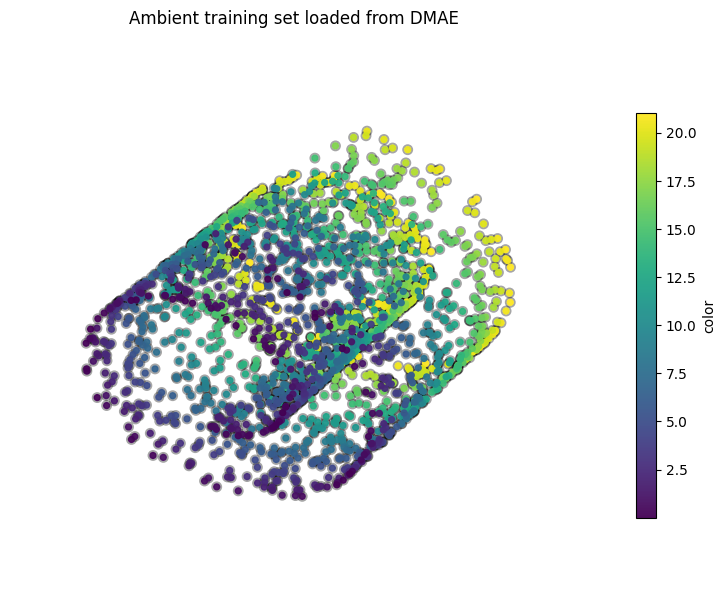

In [7]:
title = "Ambient training set loaded from DMAE"
compare_3d_plots(R_iX, R_iX, R_iX[:, 1], title, axis=False, backend="matplotlib")